# Contextual Associative Bandits [CAB]

## Part 1: Defining The Inference System

In [1]:
import torch
from pathlib import Path

# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np

import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
from idealobserver import IdealObsPFJCRP
from experiment import (
    ExperimentalEnvCRP,
    IOPFSubjectHistory,
    ExperimentHistory,
    CombinedHistory,
)
from particle import print_particle_params

/Users/youjingyu/anaconda3/envs/sofo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mcl_results_path = Path("mcl_results")
results_folder = (
    mcl_results_path
    / "prepost_static_ys_one_h_init_meta_no_y_init_rho_dim_1_removed"
    / "fourth_pass_sim"
)

In [ ]:
# def extract_context_params(folder, episode_idx=0):
#     folder = Path(folder)

#     active_means = np.load(folder / "active_means")[:, episode_idx, :]  # [T, B, 2]
#     active_sigmas = np.loadtxt(folder / "active_sigmas")[:, episode_idx]  # [T, B]
#     correct_actions = np.load(folder / "correct_actions")[
#         :, episode_idx, :
#     ]  # [T, B, 4]
#     ctxs = np.loadtxt(folder / "ctxs")  # [T]
#     class_ids = np.loadtxt(folder / "class_ids")[:, episode_idx]  # [T, B]

#     # Collect observations for each (context, class)
#     observations = {}

#     T = active_means.shape[0]

#     for t in range(T):
#         context = int(ctxs[t])

#         class_id = int(class_ids[t])
#         key = (context, class_id)

#         if key not in observations:
#             observations[key] = {
#                 "means": [],
#                 "sigmas": [],
#                 "p_rews": [],
#             }

#         observations[key]["means"].append(active_means[t])
#         observations[key]["sigmas"].append(active_sigmas[t])
#         observations[key]["p_rews"].append(correct_actions[t])

#     # ------------------------------------------------------------------
#     # Build context_o_params
#     # ------------------------------------------------------------------

#     context_o_params = {}

#     for (context, class_id), obs in sorted(observations.items()):

#         means = np.asarray(obs["means"])
#         sigmas = np.asarray(obs["sigmas"])

#         # Average across T
#         mean = means.mean(axis=0)
#         sigma = sigmas.mean()

#         # Assuming active_sigma is standard deviation
#         covariance = np.eye(2) * sigma**2

#         context_o_params.setdefault(context, {})[class_id] = {
#             "loc": torch.tensor(mean, dtype=torch.float32),
#             "cov": torch.tensor(covariance, dtype=torch.float32),
#         }

#     # ------------------------------------------------------------------
#     # Build context_r_params
#     # ------------------------------------------------------------------

#     context_r_params = {}

#     for (context, class_id), obs in sorted(observations.items()):

#         p_rews = np.asarray(obs["p_rews"])

#         # All occurrences should have the same one-hot reward
#         p_rew = p_rews[0]

#         if not np.allclose(p_rews, p_rew):
#             raise ValueError(
#                 f"Inconsistent p_rew for context={context}, "
#                 f"class={class_id}: {p_rews}"
#             )

#         # Verify one-hot
#         if not np.isclose(p_rew.sum(), 1.0):
#             raise ValueError(
#                 f"p_rew is not one-hot for context={context}, "
#                 f"class={class_id}: {p_rew}"
#             )

#         context_r_params.setdefault(context, {})[class_id] = {
#             "p_rew": torch.tensor(p_rew, dtype=torch.float32)
#         }

#     return context_o_params, context_r_params

In [ ]:
def extract_context_params(folder, episode_idx=0):
    folder = Path(folder)
    active_means = np.load(folder / "active_means")[:, episode_idx, :]
    T, B, _ = active_means.shape
    active_means = active_means[:, episode_idx, :]
    active_sigmas = np.loadtxt(folder / "active_sigmas")[:, episode_idx]
    correct_actions = np.load(folder / "correct_actions")[:, episode_idx, :]
    ctxs = np.loadtxt(folder / "ctxs")
    class_ids = np.loadtxt(folder / "class_ids")[:, episode_idx]

    # Context length: number of consecutive timesteps for each context
    changes = np.where(ctxs[1:] != ctxs[:-1])[0] + 1
    ctx_length = changes[0] if len(changes) > 0 else T

    # Optional: verify that transitions are regular
    if len(changes) > 1:
        lengths = np.diff(np.concatenate(([0], changes, [T])))
        if not np.all(lengths == ctx_length):
            raise ValueError(f"Context transitions are not regular: {lengths}")

    # Collect observations for each (context, class)
    observations = {}

    for t in range(T):
        context = int(ctxs[t])
        class_id = int(class_ids[t])
        key = (context, class_id)

        if key not in observations:
            observations[key] = {
                "means": [],
                "sigmas": [],
                "p_rews": [],
            }

        observations[key]["means"].append(active_means[t])
        observations[key]["sigmas"].append(active_sigmas[t])
        observations[key]["p_rews"].append(correct_actions[t])

    # ------------------------------------------------------------------
    # Build context_o_params
    # ------------------------------------------------------------------

    context_o_params = {}

    for (context, class_id), obs in sorted(observations.items()):
        means = np.asarray(obs["means"])
        sigmas = np.asarray(obs["sigmas"])

        mean = means.mean(axis=0)
        sigma = sigmas.mean()

        covariance = np.eye(2) * sigma**2

        context_o_params.setdefault(context, {})[class_id] = {
            "loc": torch.tensor(mean, dtype=torch.float32),
            "cov": torch.tensor(covariance, dtype=torch.float32),
        }

    # ------------------------------------------------------------------
    # Build context_r_params
    # ------------------------------------------------------------------

    context_r_params = {}

    for (context, class_id), obs in sorted(observations.items()):
        p_rews = np.asarray(obs["p_rews"])

        p_rew = p_rews[0]

        if not np.allclose(p_rews, p_rew):
            raise ValueError(
                f"Inconsistent p_rew for context={context}, "
                f"class={class_id}: {p_rews}"
            )

        if not np.isclose(p_rew.sum(), 1.0):
            raise ValueError(
                f"p_rew is not one-hot for context={context}, "
                f"class={class_id}: {p_rew}"
            )

        context_r_params.setdefault(context, {})[class_id] = {
            "p_rew": torch.tensor(p_rew, dtype=torch.float32)
        }

    return context_o_params, context_r_params, T, B, ctx_length

In [ ]:
context_o_params, context_r_params, T, B, ctx_length = extract_context_params(
    results_folder
)
n_blocks = int(T / (ctx_length * 2))

## Part 1: Defining the experiment

In [7]:
env = ExperimentalEnvCRP(
    context_o_params=context_o_params, context_r_params=context_r_params
)

## Part 2: Run Simulation

In [8]:
HYP_JCRP = {
    "gamma": 0.1,
    "alpha": 0.5,
}
HYP_NIW = {
    "mu0": torch.tensor([0.0, 0.0]),
    "kappa0": 0.1,
    "nu0": 4.0,
    "Lambda0": torch.eye(2) * 1.0,
}
HYP_BB = {
    "alpha0": torch.tensor([0.05, 0.05, 0.05, 0.05]),
    "beta0": torch.tensor([0.5, 0.5, 0.5, 0.5]),
}

HYP = {"hyp_jcrp": HYP_JCRP, "hyp_niw": HYP_NIW, "hyp_bb": HYP_BB}

#### Simulation


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.91  0.40], Action: 0, Reward: 0.0, Action probs.: [ 0.22  0.32  0.26  0.20]
Step 2:   	True state: 1, Obs.: [-1.09 -0.19], Action: 1, Reward: 1.0, Action probs.: [ 0.20  0.24  0.34  0.22]
Step 3:   	True state: 0, Obs.: [-1.98 -2.22], Action: 3, Reward: 1.0, Action probs.: [ 0.22  0.36  0.22  0.20]
Step 4:   	True state: 0, Obs.: [-1.54 -1.35], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.28  0.06  0.62]
Step 5:   	True state: 1, Obs.: [-0.24 -0.30], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.69  0.11  0.17]
Step 6:   	True state: 1, Obs.: [-0.67  0.22], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.88  0.04  0.06]
Step 7:   	True state: 0, Obs.: [-2.02 -1.32], Action: 3, Reward: 1.0, Action probs.: [ 0.01  0.10  0.07  0.81]
Step 8:   	True state: 1, Obs.: [-0.97  0.28], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.87  0.05  0.06]
Step 9:   	True state: 0, Obs.: [-1.04 -1.88], Action:

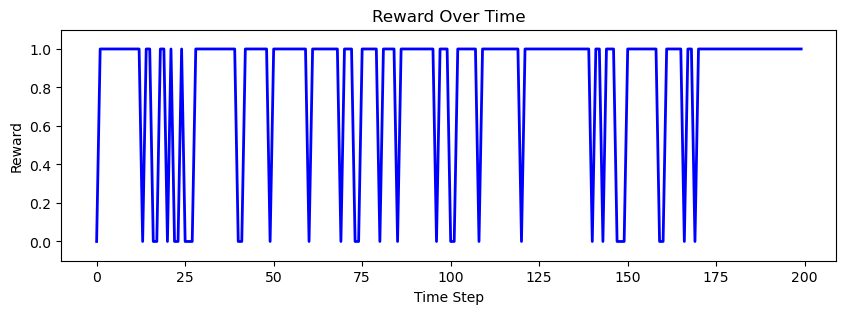


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.23 -0.12], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.25  0.28  0.23]
Step 2:   	True state: 1, Obs.: [-1.03 -0.13], Action: 0, Reward: 0.0, Action probs.: [ 0.22  0.26  0.28  0.25]
Step 3:   	True state: 0, Obs.: [-1.82 -1.33], Action: 1, Reward: 0.0, Action probs.: [ 0.19  0.25  0.34  0.22]
Step 4:   	True state: 0, Obs.: [-1.94 -0.95], Action: 1, Reward: 0.0, Action probs.: [ 0.19  0.21  0.30  0.29]
Step 5:   	True state: 0, Obs.: [-1.44 -1.88], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.21  0.28  0.28]
Step 6:   	True state: 0, Obs.: [-1.82 -1.43], Action: 0, Reward: 0.0, Action probs.: [ 0.29  0.18  0.20  0.33]
Step 7:   	True state: 0, Obs.: [-1.60 -2.07], Action: 1, Reward: 0.0, Action probs.: [ 0.20  0.18  0.29  0.33]
Step 8:   	True state: 1, Obs.: [-0.97  0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.17  0.21  0.27  0.34]
Step 9:   	True state: 1, Obs.: [-0.82 -0.43], Action:

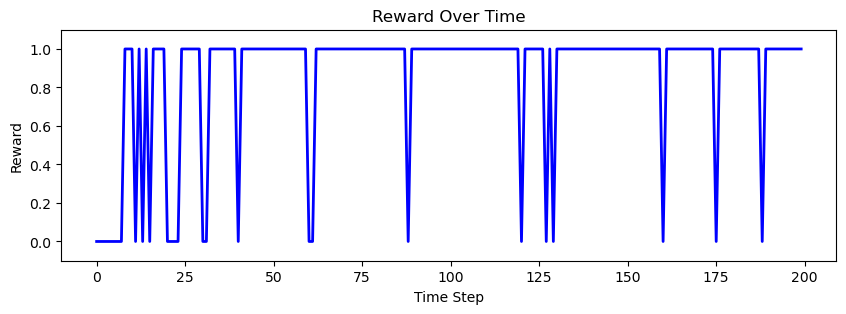


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.08  0.14], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.24  0.27  0.24]
Step 2:   	True state: 1, Obs.: [-0.44 -0.26], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.25  0.33  0.15]
Step 3:   	True state: 1, Obs.: [-0.72  0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.12  0.75  0.07  0.06]
Step 4:   	True state: 0, Obs.: [-1.53 -1.26], Action: 1, Reward: 0.0, Action probs.: [ 0.16  0.49  0.18  0.17]
Step 5:   	True state: 1, Obs.: [-0.83 -0.60], Action: 3, Reward: 0.0, Action probs.: [ 0.08  0.61  0.14  0.16]
Step 6:   	True state: 0, Obs.: [-0.88 -1.26], Action: 2, Reward: 0.0, Action probs.: [ 0.16  0.42  0.22  0.20]
Step 7:   	True state: 1, Obs.: [-0.43 -0.55], Action: 0, Reward: 0.0, Action probs.: [ 0.16  0.63  0.14  0.07]
Step 8:   	True state: 1, Obs.: [-0.87 -0.44], Action: 0, Reward: 0.0, Action probs.: [ 0.08  0.67  0.17  0.07]
Step 9:   	True state: 1, Obs.: [-0.61 -0.34], Action:

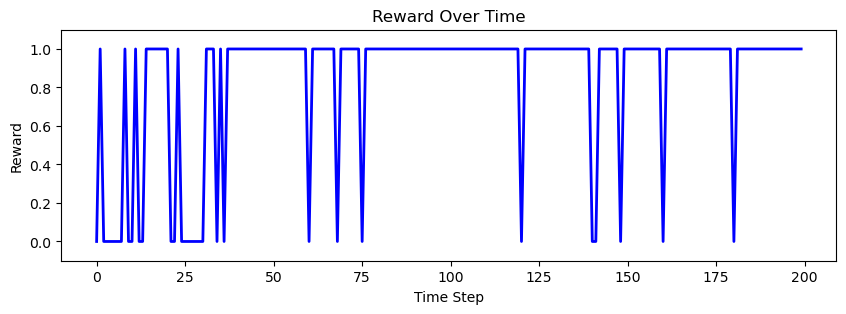


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.74  0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.29  0.26  0.21  0.25]
Step 2:   	True state: 0, Obs.: [-1.47 -1.33], Action: 1, Reward: 0.0, Action probs.: [ 0.22  0.25  0.28  0.25]
Step 3:   	True state: 1, Obs.: [-0.50 -0.03], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.25  0.28  0.27]
Step 4:   	True state: 1, Obs.: [-0.71 -0.51], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.20  0.27  0.31]
Step 5:   	True state: 0, Obs.: [-1.97 -1.38], Action: 3, Reward: 1.0, Action probs.: [ 0.28  0.19  0.27  0.26]
Step 6:   	True state: 1, Obs.: [-1.12  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.17  0.22  0.25  0.36]
Step 7:   	True state: 1, Obs.: [-0.97  0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.12  0.17  0.33  0.38]
Step 8:   	True state: 1, Obs.: [-0.64 -0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.14  0.35  0.29  0.22]
Step 9:   	True state: 0, Obs.: [-1.81 -1.84], Action:

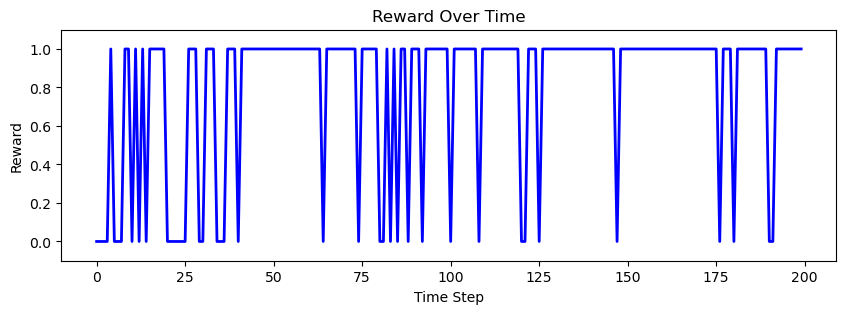


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.38 -1.62], Action: 3, Reward: 1.0, Action probs.: [ 0.23  0.25  0.23  0.29]
Step 2:   	True state: 0, Obs.: [-2.13 -1.52], Action: 3, Reward: 1.0, Action probs.: [ 0.10  0.08  0.07  0.76]
Step 3:   	True state: 1, Obs.: [-0.75 -0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.16  0.19  0.18  0.48]
Step 4:   	True state: 0, Obs.: [-1.06 -0.79], Action: 3, Reward: 1.0, Action probs.: [ 0.19  0.15  0.15  0.50]
Step 5:   	True state: 0, Obs.: [-1.37 -1.59], Action: 3, Reward: 1.0, Action probs.: [ 0.03  0.06  0.03  0.87]
Step 6:   	True state: 0, Obs.: [-2.40 -1.24], Action: 3, Reward: 1.0, Action probs.: [ 0.07  0.05  0.03  0.85]
Step 7:   	True state: 0, Obs.: [-1.89 -2.21], Action: 3, Reward: 1.0, Action probs.: [ 0.03  0.02  0.04  0.91]
Step 8:   	True state: 0, Obs.: [-1.51 -1.15], Action: 3, Reward: 1.0, Action probs.: [ 0.05  0.07  0.05  0.83]
Step 9:   	True state: 0, Obs.: [-1.54 -1.45], Action:

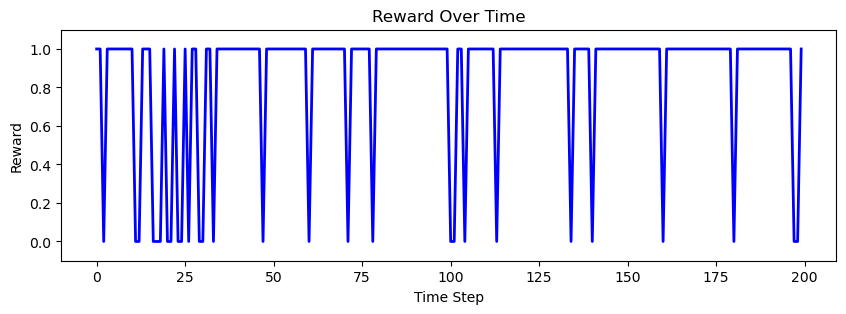


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.75 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.25  0.27  0.24]
Step 2:   	True state: 0, Obs.: [-1.28 -1.30], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.31  0.20  0.24]
Step 3:   	True state: 0, Obs.: [-1.07 -1.32], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.25  0.17  0.31]
Step 4:   	True state: 1, Obs.: [-0.19 -0.27], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.30  0.21  0.24]
Step 5:   	True state: 0, Obs.: [-1.78 -1.29], Action: 1, Reward: 0.0, Action probs.: [ 0.14  0.38  0.14  0.34]
Step 6:   	True state: 1, Obs.: [-0.49 -0.54], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.74  0.05  0.10]
Step 7:   	True state: 1, Obs.: [-0.42 -0.34], Action: 2, Reward: 0.0, Action probs.: [ 0.05  0.84  0.04  0.07]
Step 8:   	True state: 1, Obs.: [-0.45 -0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.12  0.76  0.04  0.08]
Step 9:   	True state: 1, Obs.: [-0.51 -0.19], Action:

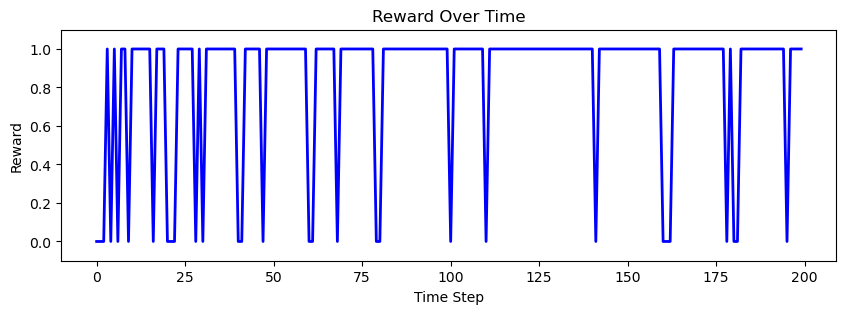


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.28 -0.33], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.30  0.24  0.26]
Step 2:   	True state: 0, Obs.: [-1.56 -0.96], Action: 0, Reward: 0.0, Action probs.: [ 0.27  0.27  0.21  0.25]
Step 3:   	True state: 0, Obs.: [-2.14 -1.35], Action: 3, Reward: 1.0, Action probs.: [ 0.21  0.28  0.27  0.24]
Step 4:   	True state: 1, Obs.: [-1.15 -0.21], Action: 3, Reward: 0.0, Action probs.: [ 0.11  0.17  0.11  0.62]
Step 5:   	True state: 1, Obs.: [-0.98 -0.46], Action: 3, Reward: 0.0, Action probs.: [ 0.17  0.19  0.11  0.53]
Step 6:   	True state: 0, Obs.: [-2.22 -1.46], Action: 3, Reward: 1.0, Action probs.: [ 0.05  0.08  0.08  0.79]
Step 7:   	True state: 1, Obs.: [-0.63 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.27  0.21  0.30]
Step 8:   	True state: 0, Obs.: [-1.45 -1.76], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.07  0.08  0.81]
Step 9:   	True state: 0, Obs.: [-2.71 -1.98], Action:

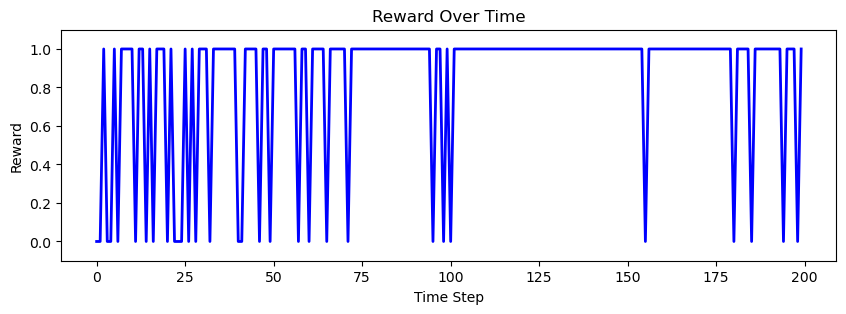


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.22 -0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.25  0.26  0.27]
Step 2:   	True state: 1, Obs.: [-0.96 -0.66], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.27  0.23  0.23]
Step 3:   	True state: 0, Obs.: [-1.39 -1.04], Action: 1, Reward: 0.0, Action probs.: [ 0.33  0.24  0.18  0.25]
Step 4:   	True state: 1, Obs.: [-1.26 -0.43], Action: 0, Reward: 0.0, Action probs.: [ 0.27  0.27  0.18  0.28]
Step 5:   	True state: 1, Obs.: [-1.00  0.22], Action: 1, Reward: 1.0, Action probs.: [ 0.21  0.28  0.23  0.28]
Step 6:   	True state: 1, Obs.: [-0.30 -0.30], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.53  0.24  0.14]
Step 7:   	True state: 0, Obs.: [-1.36 -1.67], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.39  0.27  0.12]
Step 8:   	True state: 1, Obs.: [-0.59  0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.79  0.05  0.07]
Step 9:   	True state: 0, Obs.: [-1.48 -1.43], Action:

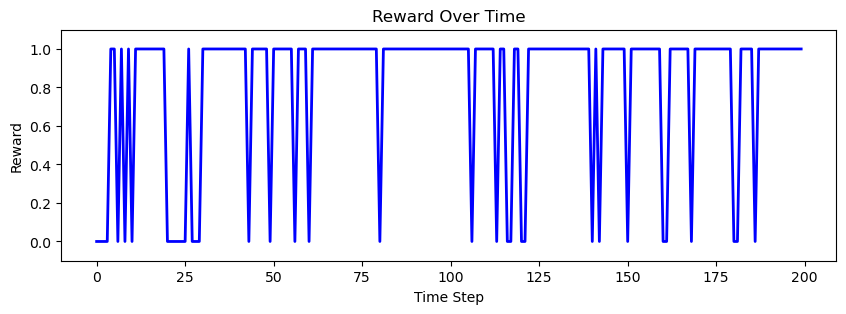


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.31 -1.81], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.24  0.24  0.26]
Step 2:   	True state: 1, Obs.: [-0.46 -0.27], Action: 1, Reward: 1.0, Action probs.: [ 0.32  0.22  0.20  0.26]
Step 3:   	True state: 0, Obs.: [-1.46 -1.86], Action: 3, Reward: 1.0, Action probs.: [ 0.21  0.47  0.14  0.17]
Step 4:   	True state: 1, Obs.: [-0.89  0.18], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.72  0.05  0.16]
Step 5:   	True state: 1, Obs.: [-1.09 -0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.03  0.78  0.06  0.13]
Step 6:   	True state: 0, Obs.: [-1.70 -1.44], Action: 1, Reward: 0.0, Action probs.: [ 0.02  0.07  0.02  0.89]
Step 7:   	True state: 0, Obs.: [-1.64 -1.10], Action: 3, Reward: 1.0, Action probs.: [ 0.08  0.14  0.01  0.77]
Step 8:   	True state: 0, Obs.: [-1.64 -1.45], Action: 3, Reward: 1.0, Action probs.: [ 0.01  0.06  0.00  0.93]
Step 9:   	True state: 0, Obs.: [-1.12 -1.85], Action:

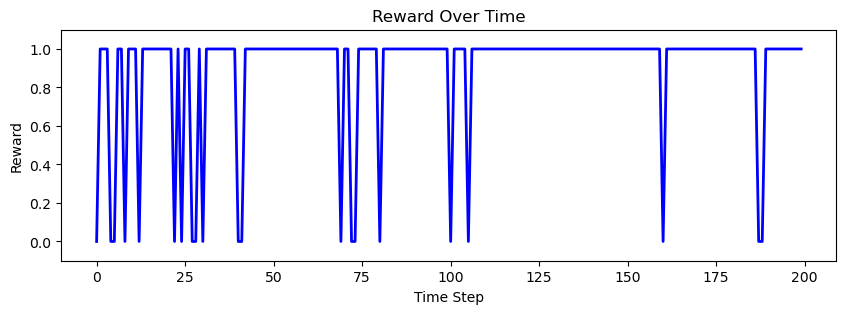


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97  0.32], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.23  0.24  0.27]
Step 2:   	True state: 1, Obs.: [-0.24 -0.53], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.29  0.21  0.27]
Step 3:   	True state: 0, Obs.: [-1.82 -1.69], Action: 1, Reward: 0.0, Action probs.: [ 0.20  0.44  0.15  0.21]
Step 4:   	True state: 0, Obs.: [-1.71 -1.13], Action: 0, Reward: 0.0, Action probs.: [ 0.22  0.30  0.24  0.25]
Step 5:   	True state: 0, Obs.: [-1.37 -1.31], Action: 0, Reward: 0.0, Action probs.: [ 0.18  0.34  0.22  0.26]
Step 6:   	True state: 0, Obs.: [-1.72 -1.78], Action: 0, Reward: 0.0, Action probs.: [ 0.18  0.30  0.30  0.22]
Step 7:   	True state: 1, Obs.: [-0.93 -0.29], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.76  0.06  0.13]
Step 8:   	True state: 0, Obs.: [-1.85 -1.40], Action: 1, Reward: 0.0, Action probs.: [ 0.21  0.24  0.23  0.31]
Step 9:   	True state: 0, Obs.: [-1.45 -0.89], Action:

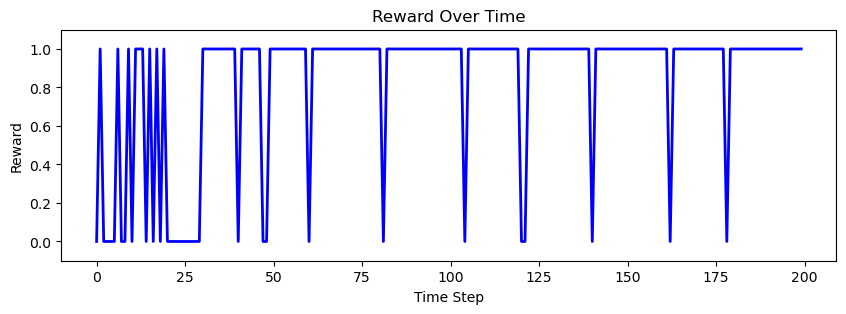


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.34 -0.27], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.26  0.26  0.24]
Step 2:   	True state: 1, Obs.: [-1.16  0.48], Action: 0, Reward: 0.0, Action probs.: [ 0.30  0.24  0.20  0.27]
Step 3:   	True state: 1, Obs.: [-0.67 -0.19], Action: 0, Reward: 0.0, Action probs.: [ 0.22  0.24  0.22  0.32]
Step 4:   	True state: 1, Obs.: [-1.37 -0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.20  0.27  0.22  0.31]
Step 5:   	True state: 0, Obs.: [-1.29 -1.72], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.21  0.27  0.30]
Step 6:   	True state: 0, Obs.: [-1.77 -1.35], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.28  0.21  0.28]
Step 7:   	True state: 1, Obs.: [-0.92  0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.33  0.21  0.23]
Step 8:   	True state: 0, Obs.: [-1.77 -1.60], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.35  0.17  0.22]
Step 9:   	True state: 0, Obs.: [-1.60 -1.28], Action:

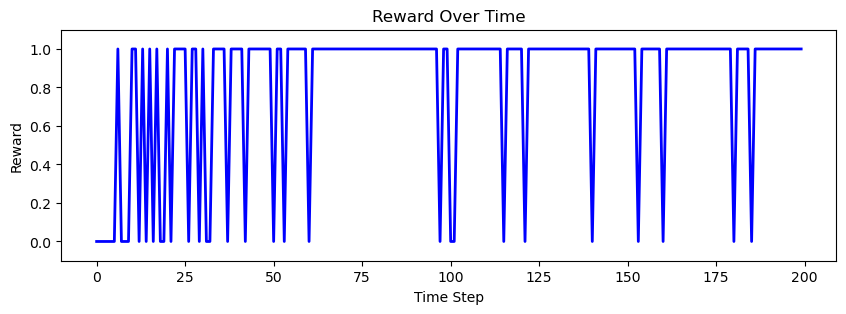


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.69 -1.89], Action: 3, Reward: 1.0, Action probs.: [ 0.25  0.32  0.23  0.21]
Step 2:   	True state: 0, Obs.: [-1.86 -1.74], Action: 3, Reward: 1.0, Action probs.: [ 0.12  0.07  0.04  0.77]
Step 3:   	True state: 1, Obs.: [-1.07  0.27], Action: 0, Reward: 0.0, Action probs.: [ 0.18  0.23  0.19  0.40]
Step 4:   	True state: 0, Obs.: [-1.51 -1.24], Action: 0, Reward: 0.0, Action probs.: [ 0.05  0.09  0.04  0.83]
Step 5:   	True state: 0, Obs.: [-1.66 -2.12], Action: 3, Reward: 1.0, Action probs.: [ 0.03  0.06  0.07  0.84]
Step 6:   	True state: 0, Obs.: [-1.24 -1.59], Action: 3, Reward: 1.0, Action probs.: [ 0.01  0.04  0.04  0.91]
Step 7:   	True state: 1, Obs.: [-0.76 -0.22], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.28  0.19  0.33]
Step 8:   	True state: 1, Obs.: [-0.48 -0.22], Action: 3, Reward: 0.0, Action probs.: [ 0.20  0.24  0.22  0.34]
Step 9:   	True state: 0, Obs.: [-1.37 -1.65], Action:

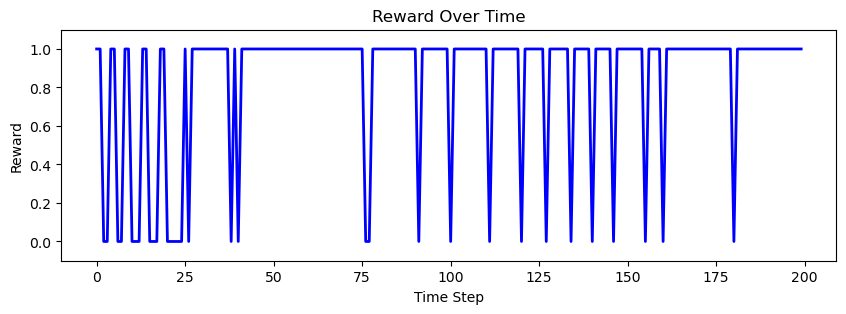


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-2.23 -1.55], Action: 3, Reward: 1.0, Action probs.: [ 0.24  0.29  0.24  0.23]
Step 2:   	True state: 0, Obs.: [-2.32 -1.75], Action: 3, Reward: 1.0, Action probs.: [ 0.07  0.10  0.08  0.75]
Step 3:   	True state: 1, Obs.: [-0.94 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.15  0.19  0.45]
Step 4:   	True state: 1, Obs.: [-0.92 -0.28], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.71  0.04  0.18]
Step 5:   	True state: 0, Obs.: [-2.08 -1.29], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.13  0.05  0.78]
Step 6:   	True state: 1, Obs.: [-0.36 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.77  0.04  0.12]
Step 7:   	True state: 0, Obs.: [-1.62 -1.53], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.06  0.01  0.89]
Step 8:   	True state: 1, Obs.: [-1.13 -0.38], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.80  0.04  0.12]
Step 9:   	True state: 0, Obs.: [-1.89 -1.14], Action:

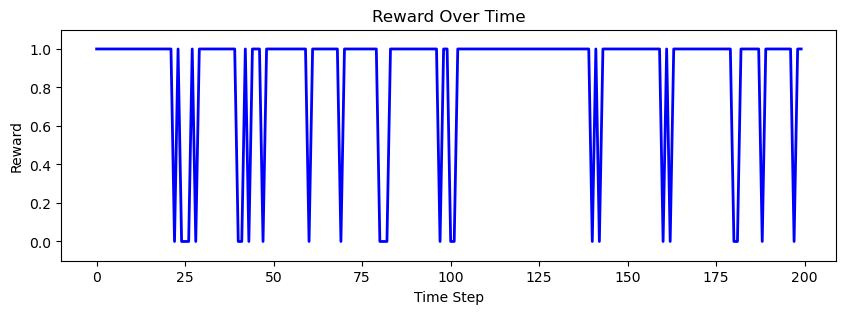


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.55 -1.54], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.20  0.28  0.26]
Step 2:   	True state: 1, Obs.: [-1.13  0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.26  0.25  0.29]
Step 3:   	True state: 1, Obs.: [-0.78 -0.43], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.26  0.24  0.27]
Step 4:   	True state: 1, Obs.: [-0.24  0.19], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.26  0.21  0.27]
Step 5:   	True state: 1, Obs.: [-0.42 -0.45], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.28  0.20  0.30]
Step 6:   	True state: 1, Obs.: [-0.44 -0.23], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.35  0.21  0.16]
Step 7:   	True state: 0, Obs.: [-1.65 -1.45], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.28  0.22  0.26]
Step 8:   	True state: 1, Obs.: [-1.26 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.19  0.33  0.25  0.23]
Step 9:   	True state: 0, Obs.: [-1.23 -1.29], Action:

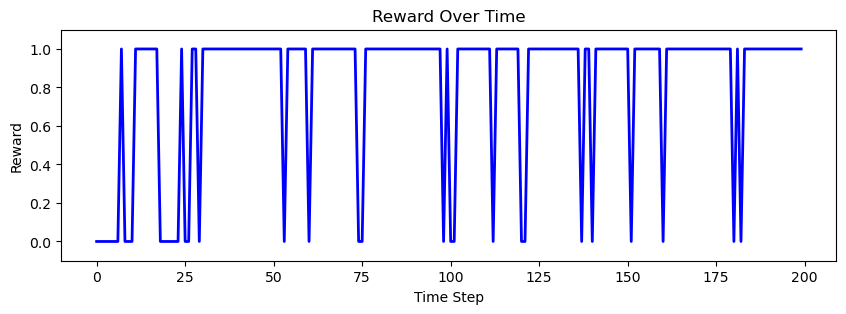


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.60 -1.61], Action: 3, Reward: 1.0, Action probs.: [ 0.26  0.20  0.24  0.31]
Step 2:   	True state: 0, Obs.: [-1.54 -1.25], Action: 3, Reward: 1.0, Action probs.: [ 0.08  0.05  0.07  0.80]
Step 3:   	True state: 0, Obs.: [-1.97 -2.39], Action: 3, Reward: 1.0, Action probs.: [ 0.07  0.04  0.06  0.84]
Step 4:   	True state: 0, Obs.: [-1.79 -1.64], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.05  0.04  0.86]
Step 5:   	True state: 0, Obs.: [-1.93 -1.77], Action: 3, Reward: 1.0, Action probs.: [ 0.03  0.04  0.04  0.88]
Step 6:   	True state: 0, Obs.: [-1.59 -1.77], Action: 3, Reward: 1.0, Action probs.: [ 0.01  0.04  0.02  0.94]
Step 7:   	True state: 1, Obs.: [-0.93  0.28], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.21  0.22  0.35]
Step 8:   	True state: 0, Obs.: [-1.34 -1.64], Action: 3, Reward: 1.0, Action probs.: [ 0.05  0.04  0.04  0.87]
Step 9:   	True state: 1, Obs.: [-1.03  0.13], Action:

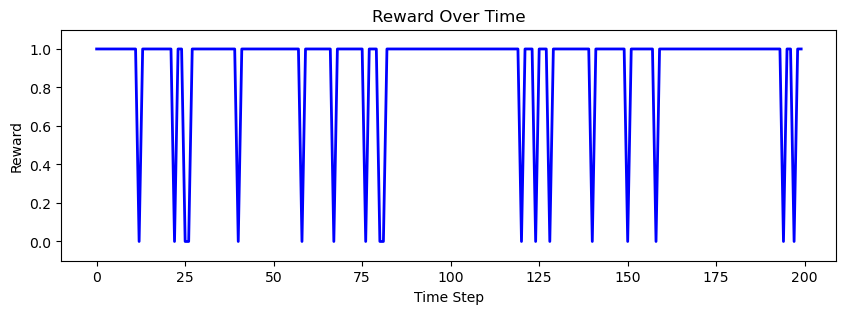


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-2.04 -1.49], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.22  0.26  0.28]
Step 2:   	True state: 0, Obs.: [-1.30 -1.29], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.29  0.14  0.29]
Step 3:   	True state: 1, Obs.: [-0.33 -0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.29  0.25  0.21  0.25]
Step 4:   	True state: 0, Obs.: [-1.18 -1.78], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.30  0.17  0.27]
Step 5:   	True state: 1, Obs.: [-0.27 -0.34], Action: 0, Reward: 0.0, Action probs.: [ 0.11  0.76  0.06  0.08]
Step 6:   	True state: 0, Obs.: [-1.51 -1.37], Action: 2, Reward: 0.0, Action probs.: [ 0.30  0.17  0.19  0.35]
Step 7:   	True state: 0, Obs.: [-0.81 -1.75], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.30  0.16  0.31]
Step 8:   	True state: 0, Obs.: [-1.24 -1.74], Action: 3, Reward: 1.0, Action probs.: [ 0.28  0.25  0.20  0.27]
Step 9:   	True state: 1, Obs.: [-0.60  0.06], Action:

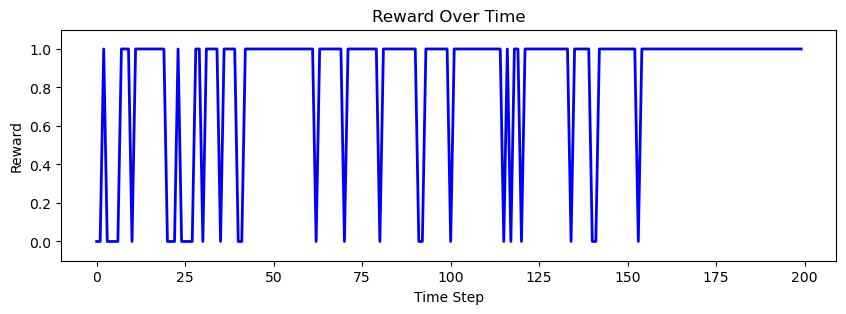


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.83  0.42], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.26  0.29  0.24]
Step 2:   	True state: 0, Obs.: [-1.59 -1.38], Action: 3, Reward: 1.0, Action probs.: [ 0.16  0.50  0.11  0.23]
Step 3:   	True state: 1, Obs.: [-1.20  0.11], Action: 3, Reward: 0.0, Action probs.: [ 0.06  0.61  0.07  0.27]
Step 4:   	True state: 0, Obs.: [-1.73 -1.61], Action: 3, Reward: 1.0, Action probs.: [ 0.10  0.08  0.09  0.72]
Step 5:   	True state: 0, Obs.: [-1.36 -1.98], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.08  0.02  0.86]
Step 6:   	True state: 0, Obs.: [-1.57 -2.22], Action: 3, Reward: 1.0, Action probs.: [ 0.01  0.05  0.05  0.89]
Step 7:   	True state: 1, Obs.: [-0.72 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.79  0.09  0.07]
Step 8:   	True state: 1, Obs.: [-1.29  0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.86  0.06  0.05]
Step 9:   	True state: 1, Obs.: [-0.69 -0.34], Action:

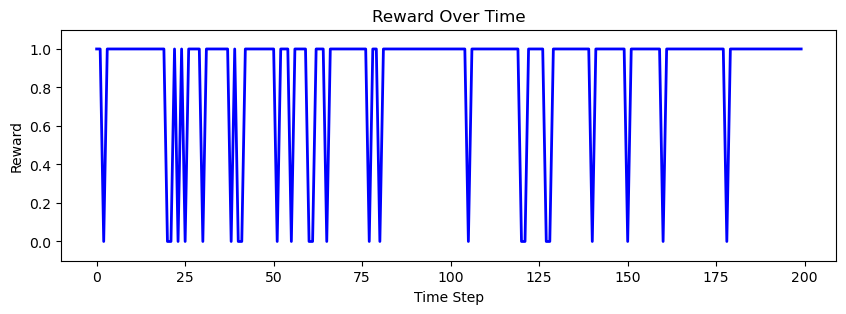


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-2.04 -1.53], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.24  0.30  0.23]
Step 2:   	True state: 1, Obs.: [-0.67 -0.20], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.25  0.22  0.30]
Step 3:   	True state: 1, Obs.: [-1.08 -0.29], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.29  0.19  0.26]
Step 4:   	True state: 0, Obs.: [-1.57 -1.80], Action: 3, Reward: 1.0, Action probs.: [ 0.19  0.48  0.14  0.19]
Step 5:   	True state: 0, Obs.: [-1.84 -1.35], Action: 3, Reward: 1.0, Action probs.: [ 0.10  0.22  0.04  0.64]
Step 6:   	True state: 1, Obs.: [-0.67 -0.48], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.69  0.01  0.23]
Step 7:   	True state: 0, Obs.: [-1.42 -1.63], Action: 3, Reward: 1.0, Action probs.: [ 0.07  0.12  0.01  0.80]
Step 8:   	True state: 1, Obs.: [-0.85  0.37], Action: 3, Reward: 0.0, Action probs.: [ 0.05  0.87  0.02  0.05]
Step 9:   	True state: 0, Obs.: [-1.78 -1.75], Action:

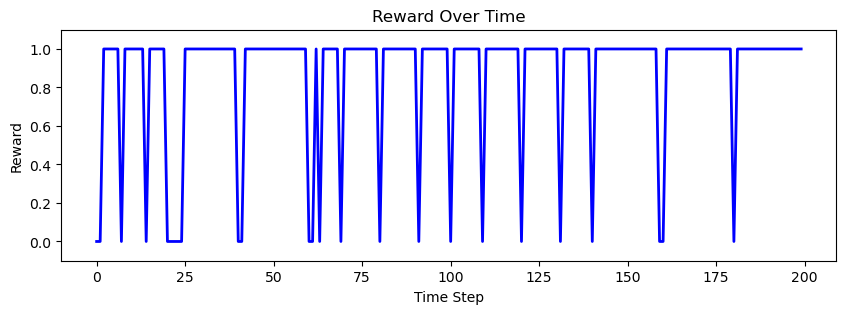


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.53 -0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.21  0.30  0.26]
Step 2:   	True state: 0, Obs.: [-2.19 -1.28], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.30  0.20  0.25]
Step 3:   	True state: 0, Obs.: [-2.19 -1.60], Action: 3, Reward: 1.0, Action probs.: [ 0.32  0.17  0.30  0.21]
Step 4:   	True state: 0, Obs.: [-1.63 -1.41], Action: 3, Reward: 1.0, Action probs.: [ 0.07  0.03  0.07  0.82]
Step 5:   	True state: 1, Obs.: [-0.56 -0.62], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.22  0.13  0.43]
Step 6:   	True state: 1, Obs.: [-1.14  0.70], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.77  0.04  0.13]
Step 7:   	True state: 1, Obs.: [-0.80 -0.18], Action: 0, Reward: 0.0, Action probs.: [ 0.05  0.83  0.02  0.10]
Step 8:   	True state: 1, Obs.: [-1.17  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.03  0.87  0.02  0.09]
Step 9:   	True state: 0, Obs.: [-1.48 -2.00], Action:

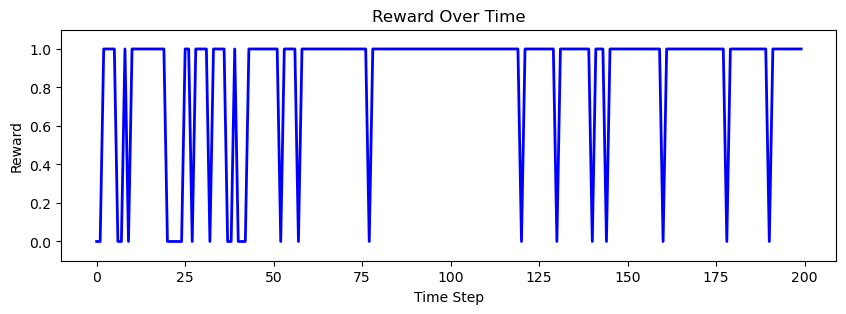


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.58 -1.49], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.27  0.23  0.25]
Step 2:   	True state: 0, Obs.: [-1.30 -1.66], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.25  0.26  0.28]
Step 3:   	True state: 1, Obs.: [-0.21 -0.50], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.27  0.21  0.31]
Step 4:   	True state: 1, Obs.: [-0.36 -0.39], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.25  0.32  0.24]
Step 5:   	True state: 1, Obs.: [-0.89 -0.37], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.22  0.26  0.31]
Step 6:   	True state: 0, Obs.: [-1.51 -1.70], Action: 3, Reward: 1.0, Action probs.: [ 0.20  0.40  0.15  0.24]
Step 7:   	True state: 0, Obs.: [-2.15 -1.00], Action: 3, Reward: 1.0, Action probs.: [ 0.02  0.27  0.03  0.69]
Step 8:   	True state: 1, Obs.: [-0.48 -0.32], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.85  0.02  0.09]
Step 9:   	True state: 0, Obs.: [-1.82 -2.26], Action:

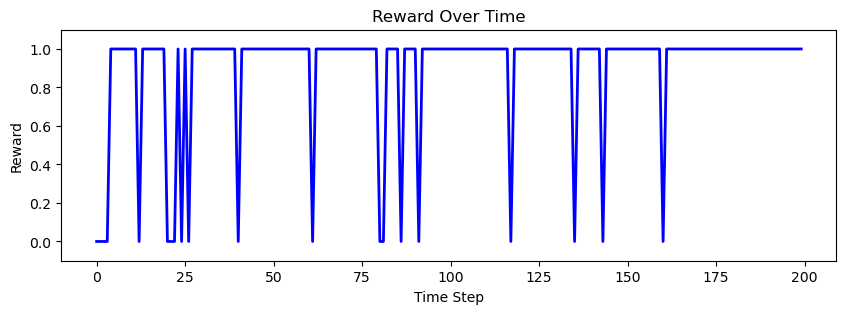


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.94  0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.25  0.25  0.26]
Step 2:   	True state: 0, Obs.: [-1.82 -1.55], Action: 2, Reward: 0.0, Action probs.: [ 0.15  0.47  0.18  0.20]
Step 3:   	True state: 0, Obs.: [-1.07 -1.43], Action: 0, Reward: 0.0, Action probs.: [ 0.19  0.56  0.12  0.14]
Step 4:   	True state: 0, Obs.: [-2.01 -2.18], Action: 2, Reward: 0.0, Action probs.: [ 0.15  0.46  0.19  0.20]
Step 5:   	True state: 0, Obs.: [-2.17 -2.01], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.35  0.16  0.24]
Step 6:   	True state: 0, Obs.: [-1.48 -1.49], Action: 3, Reward: 1.0, Action probs.: [ 0.22  0.31  0.17  0.30]
Step 7:   	True state: 0, Obs.: [-1.03 -1.57], Action: 1, Reward: 0.0, Action probs.: [ 0.04  0.17  0.02  0.76]
Step 8:   	True state: 1, Obs.: [-1.08 -0.34], Action: 3, Reward: 0.0, Action probs.: [ 0.06  0.76  0.01  0.18]
Step 9:   	True state: 0, Obs.: [-2.34 -2.04], Action:

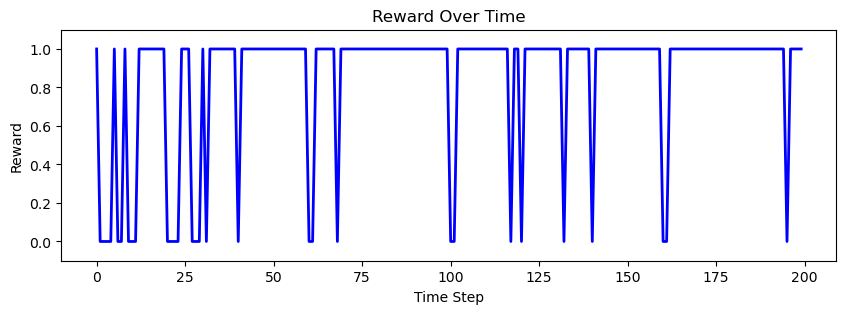


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.34  0.23], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.27  0.27  0.21]
Step 2:   	True state: 1, Obs.: [-1.12 -0.61], Action: 0, Reward: 0.0, Action probs.: [ 0.11  0.62  0.13  0.14]
Step 3:   	True state: 0, Obs.: [-1.72 -1.92], Action: 2, Reward: 0.0, Action probs.: [ 0.16  0.48  0.20  0.16]
Step 4:   	True state: 1, Obs.: [-0.69  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.77  0.08  0.10]
Step 5:   	True state: 0, Obs.: [-1.77 -1.79], Action: 3, Reward: 1.0, Action probs.: [ 0.17  0.38  0.19  0.26]
Step 6:   	True state: 1, Obs.: [-0.80  0.71], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.86  0.05  0.08]
Step 7:   	True state: 1, Obs.: [-1.14 -0.75], Action: 3, Reward: 0.0, Action probs.: [ 0.04  0.44  0.04  0.48]
Step 8:   	True state: 1, Obs.: [-0.62  0.18], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.88  0.02  0.07]
Step 9:   	True state: 0, Obs.: [-1.66 -1.22], Action:

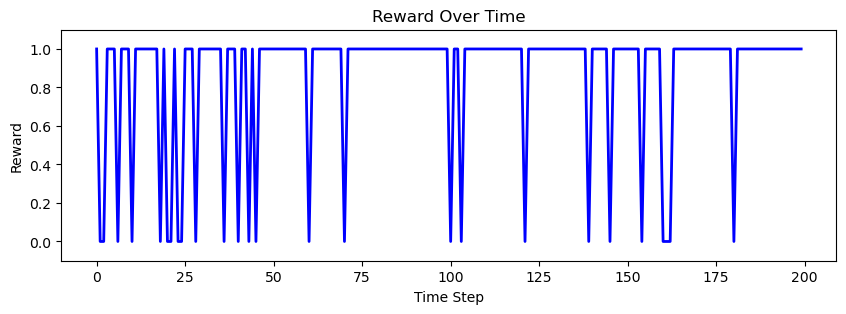


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.46 -1.36], Action: 3, Reward: 1.0, Action probs.: [ 0.23  0.24  0.32  0.20]
Step 2:   	True state: 0, Obs.: [-1.45 -1.94], Action: 0, Reward: 0.0, Action probs.: [ 0.09  0.07  0.08  0.76]
Step 3:   	True state: 0, Obs.: [-2.21 -1.43], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.10  0.10  0.75]
Step 4:   	True state: 1, Obs.: [-0.40 -0.27], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.18  0.19  0.44]
Step 5:   	True state: 1, Obs.: [-0.67  0.17], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.21  0.19  0.39]
Step 6:   	True state: 0, Obs.: [-1.55 -1.16], Action: 3, Reward: 1.0, Action probs.: [ 0.03  0.07  0.07  0.82]
Step 7:   	True state: 1, Obs.: [-1.05  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.20  0.14  0.37]
Step 8:   	True state: 1, Obs.: [-0.73 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.78  0.01  0.13]
Step 9:   	True state: 1, Obs.: [ 0.20 -0.09], Action:

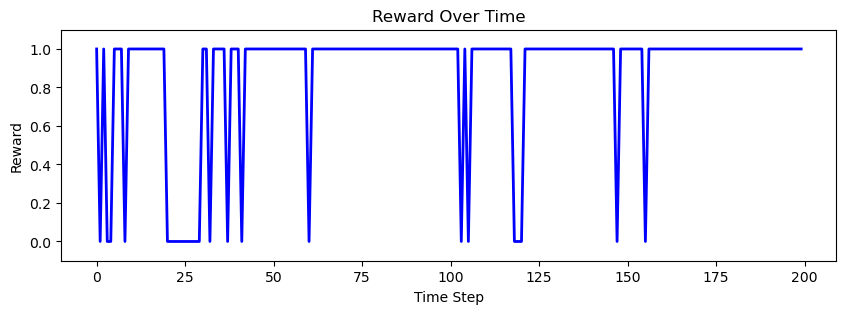


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.59 -2.11], Action: 1, Reward: 0.0, Action probs.: [ 0.23  0.29  0.22  0.26]
Step 2:   	True state: 0, Obs.: [-1.68 -1.68], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.24  0.32  0.19]
Step 3:   	True state: 1, Obs.: [-0.86  0.55], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.27  0.19  0.26]
Step 4:   	True state: 1, Obs.: [-0.66 -0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.28  0.28  0.18]
Step 5:   	True state: 0, Obs.: [-1.91 -1.77], Action: 3, Reward: 1.0, Action probs.: [ 0.29  0.20  0.25  0.26]
Step 6:   	True state: 1, Obs.: [-0.53 -0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.30  0.28  0.20  0.22]
Step 7:   	True state: 1, Obs.: [-0.38 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.27  0.30  0.21]
Step 8:   	True state: 1, Obs.: [-1.01 -0.23], Action: 0, Reward: 0.0, Action probs.: [ 0.21  0.31  0.16  0.32]
Step 9:   	True state: 1, Obs.: [-0.67  0.24], Action:

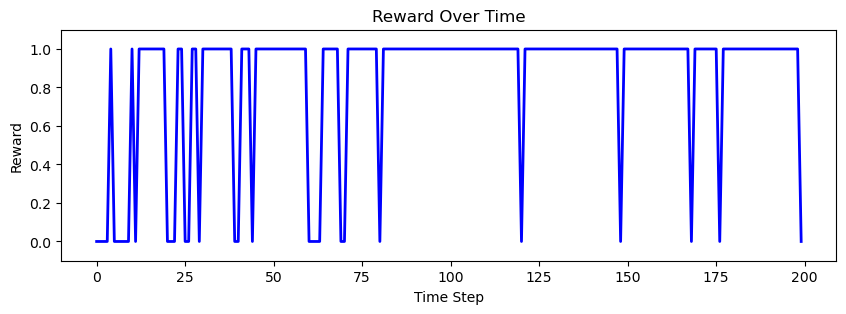


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.28 -0.85], Action: 3, Reward: 1.0, Action probs.: [ 0.22  0.26  0.27  0.26]
Step 2:   	True state: 0, Obs.: [-1.72 -2.03], Action: 3, Reward: 1.0, Action probs.: [ 0.08  0.12  0.09  0.71]
Step 3:   	True state: 1, Obs.: [-0.96 -0.24], Action: 3, Reward: 0.0, Action probs.: [ 0.07  0.11  0.11  0.70]
Step 4:   	True state: 0, Obs.: [-1.60 -1.61], Action: 3, Reward: 1.0, Action probs.: [ 0.10  0.04  0.05  0.81]
Step 5:   	True state: 0, Obs.: [-1.67 -2.05], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.07  0.05  0.84]
Step 6:   	True state: 1, Obs.: [-0.89 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.17  0.25  0.33]
Step 7:   	True state: 1, Obs.: [-0.68  0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.73  0.09  0.11]
Step 8:   	True state: 0, Obs.: [-1.61 -1.92], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.05  0.04  0.87]
Step 9:   	True state: 0, Obs.: [-1.27 -1.84], Action:

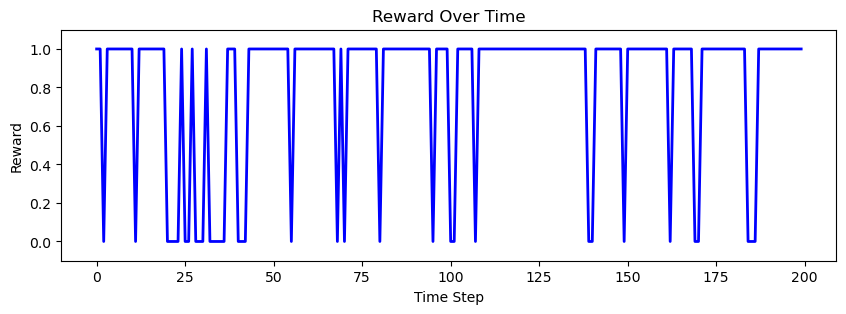


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.50 -1.83], Action: 1, Reward: 0.0, Action probs.: [ 0.20  0.27  0.26  0.28]
Step 2:   	True state: 0, Obs.: [-1.42 -1.25], Action: 3, Reward: 1.0, Action probs.: [ 0.26  0.16  0.31  0.27]
Step 3:   	True state: 0, Obs.: [-1.52 -1.76], Action: 3, Reward: 1.0, Action probs.: [ 0.07  0.04  0.06  0.83]
Step 4:   	True state: 1, Obs.: [-0.54  0.35], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.17  0.28  0.32]
Step 5:   	True state: 0, Obs.: [-1.75 -1.22], Action: 3, Reward: 1.0, Action probs.: [ 0.06  0.05  0.02  0.87]
Step 6:   	True state: 0, Obs.: [-1.69 -1.72], Action: 3, Reward: 1.0, Action probs.: [ 0.02  0.02  0.04  0.92]
Step 7:   	True state: 0, Obs.: [-1.33 -1.81], Action: 3, Reward: 1.0, Action probs.: [ 0.02  0.00  0.04  0.94]
Step 8:   	True state: 1, Obs.: [-1.30 -0.45], Action: 3, Reward: 0.0, Action probs.: [ 0.03  0.55  0.04  0.38]
Step 9:   	True state: 0, Obs.: [-2.41 -1.08], Action:

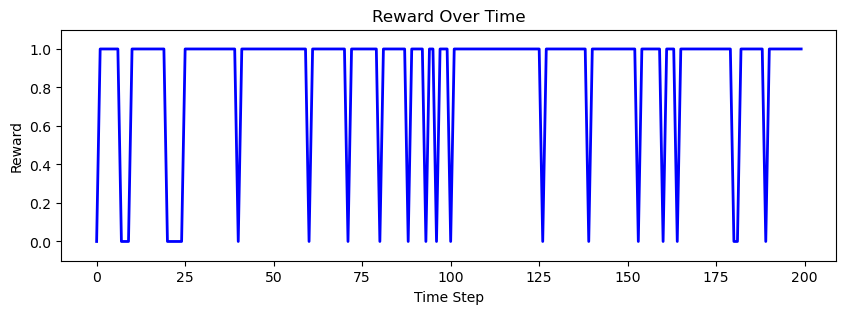


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.65 -2.10], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.28  0.24  0.23]
Step 2:   	True state: 1, Obs.: [-0.41 -0.66], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.26  0.21  0.26]
Step 3:   	True state: 1, Obs.: [-0.61 -0.36], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.28  0.23  0.24]
Step 4:   	True state: 0, Obs.: [-1.32 -1.62], Action: 3, Reward: 1.0, Action probs.: [ 0.25  0.24  0.23  0.29]
Step 5:   	True state: 1, Obs.: [-0.84 -0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.13  0.26  0.15  0.46]
Step 6:   	True state: 0, Obs.: [-1.91 -1.03], Action: 3, Reward: 1.0, Action probs.: [ 0.11  0.12  0.04  0.73]
Step 7:   	True state: 0, Obs.: [-1.15 -1.54], Action: 0, Reward: 0.0, Action probs.: [ 0.07  0.06  0.02  0.86]
Step 8:   	True state: 0, Obs.: [-1.98 -1.77], Action: 3, Reward: 1.0, Action probs.: [ 0.02  0.02  0.01  0.95]
Step 9:   	True state: 1, Obs.: [-1.20  0.34], Action:

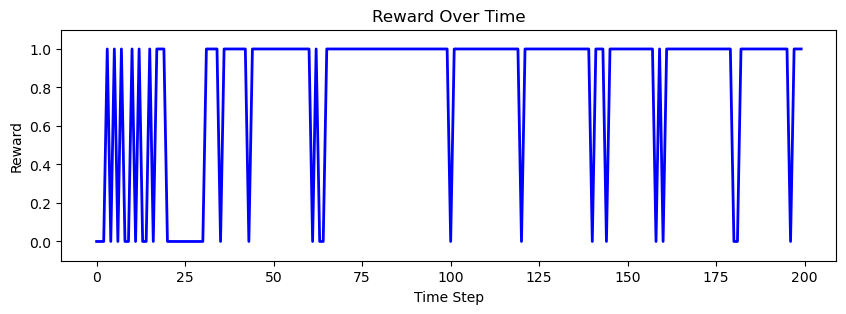


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.62 -1.70], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.24  0.25  0.25]
Step 2:   	True state: 0, Obs.: [-1.34 -0.88], Action: 3, Reward: 1.0, Action probs.: [ 0.32  0.28  0.18  0.23]
Step 3:   	True state: 0, Obs.: [-2.05 -1.89], Action: 0, Reward: 0.0, Action probs.: [ 0.14  0.09  0.04  0.74]
Step 4:   	True state: 1, Obs.: [-0.69 -0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.14  0.14  0.09  0.63]
Step 5:   	True state: 0, Obs.: [-1.68 -1.23], Action: 3, Reward: 1.0, Action probs.: [ 0.04  0.13  0.05  0.78]
Step 6:   	True state: 1, Obs.: [-0.37  0.06], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.20  0.25  0.29]
Step 7:   	True state: 1, Obs.: [-0.54 -0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.29  0.26  0.25]
Step 8:   	True state: 0, Obs.: [-1.91 -1.30], Action: 3, Reward: 1.0, Action probs.: [ 0.01  0.05  0.02  0.91]
Step 9:   	True state: 0, Obs.: [-1.95 -2.06], Action:

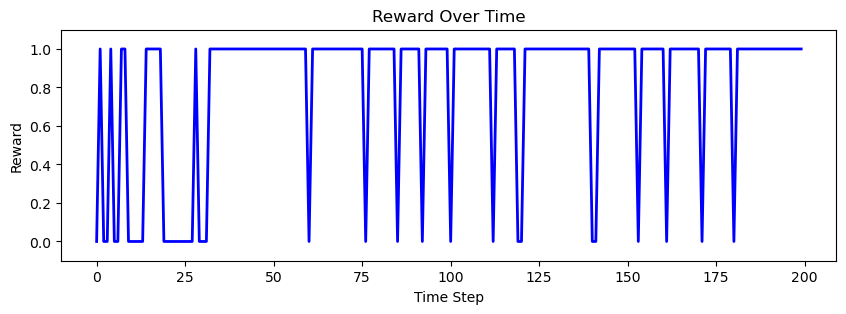


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.64 -0.35], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.22  0.28  0.26]
Step 2:   	True state: 1, Obs.: [-0.75 -0.29], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.75  0.06  0.10]
Step 3:   	True state: 1, Obs.: [-1.14 -0.41], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.84  0.06  0.05]
Step 4:   	True state: 0, Obs.: [-2.18 -1.45], Action: 0, Reward: 0.0, Action probs.: [ 0.14  0.48  0.21  0.17]
Step 5:   	True state: 0, Obs.: [-1.06 -1.40], Action: 1, Reward: 0.0, Action probs.: [ 0.11  0.52  0.16  0.21]
Step 6:   	True state: 0, Obs.: [-1.94 -1.26], Action: 1, Reward: 0.0, Action probs.: [ 0.17  0.31  0.22  0.30]
Step 7:   	True state: 0, Obs.: [-1.14 -1.12], Action: 2, Reward: 0.0, Action probs.: [ 0.19  0.40  0.19  0.22]
Step 8:   	True state: 1, Obs.: [-0.36 -0.91], Action: 2, Reward: 0.0, Action probs.: [ 0.09  0.64  0.11  0.15]
Step 9:   	True state: 0, Obs.: [-1.49 -1.56], Action:

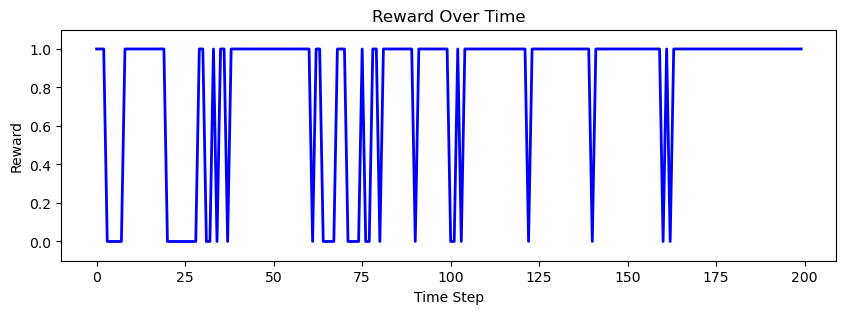


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-1.33 -1.39], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.25  0.26  0.25]
Step 2:   	True state: 0, Obs.: [-2.11 -2.00], Action: 0, Reward: 0.0, Action probs.: [ 0.18  0.26  0.27  0.28]
Step 3:   	True state: 0, Obs.: [-1.30 -1.38], Action: 1, Reward: 0.0, Action probs.: [ 0.13  0.28  0.31  0.27]
Step 4:   	True state: 0, Obs.: [-1.61 -1.62], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.21  0.30  0.29]
Step 5:   	True state: 0, Obs.: [-1.66 -1.34], Action: 0, Reward: 0.0, Action probs.: [ 0.18  0.21  0.32  0.28]
Step 6:   	True state: 1, Obs.: [-0.94  0.26], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.25  0.26  0.23]
Step 7:   	True state: 0, Obs.: [-1.19 -1.48], Action: 3, Reward: 1.0, Action probs.: [ 0.20  0.27  0.27  0.26]
Step 8:   	True state: 0, Obs.: [-1.35 -1.54], Action: 3, Reward: 1.0, Action probs.: [ 0.02  0.09  0.06  0.83]
Step 9:   	True state: 0, Obs.: [-2.20 -1.46], Action:

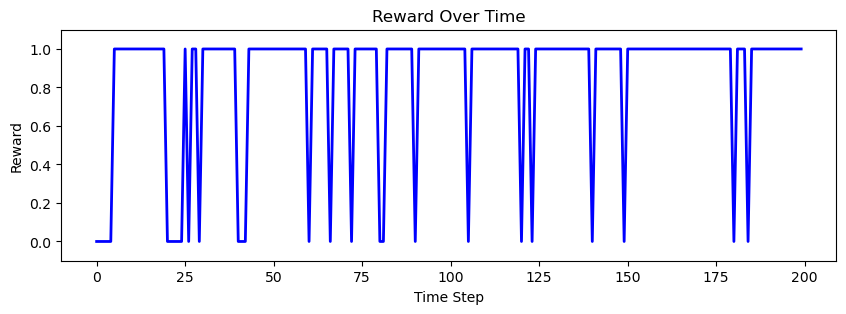


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.22  0.47], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.25  0.25  0.23]
Step 2:   	True state: 0, Obs.: [-1.94 -1.85], Action: 3, Reward: 1.0, Action probs.: [ 0.22  0.29  0.23  0.26]
Step 3:   	True state: 1, Obs.: [-0.29 -0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.16  0.25  0.20  0.39]
Step 4:   	True state: 1, Obs.: [-1.04 -0.16], Action: 2, Reward: 0.0, Action probs.: [ 0.05  0.64  0.06  0.25]
Step 5:   	True state: 1, Obs.: [-0.55 -0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.70  0.05  0.19]
Step 6:   	True state: 0, Obs.: [-1.93 -1.59], Action: 3, Reward: 1.0, Action probs.: [ 0.06  0.09  0.06  0.79]
Step 7:   	True state: 1, Obs.: [-0.91 -0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.90  0.02  0.07]
Step 8:   	True state: 0, Obs.: [-1.64 -1.79], Action: 3, Reward: 1.0, Action probs.: [ 0.05  0.05  0.05  0.85]
Step 9:   	True state: 1, Obs.: [-0.54 -0.07], Action:

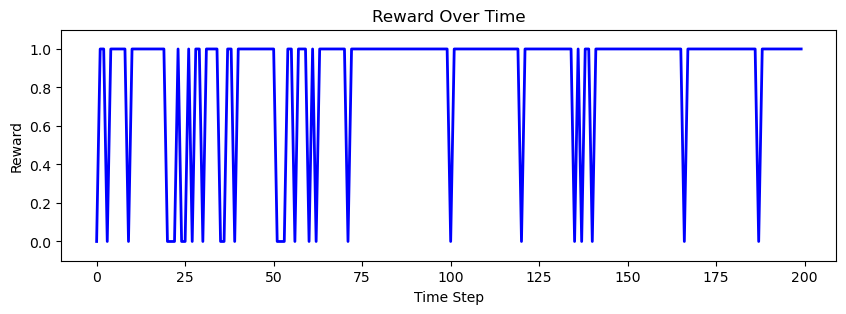


 << Running 20 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [-0.94 -1.74], Action: 3, Reward: 1.0, Action probs.: [ 0.26  0.22  0.24  0.29]
Step 2:   	True state: 0, Obs.: [-1.84 -1.74], Action: 3, Reward: 1.0, Action probs.: [ 0.06  0.09  0.12  0.73]
Step 3:   	True state: 1, Obs.: [-0.74  0.48], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.20  0.24  0.33]
Step 4:   	True state: 1, Obs.: [-0.97  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.17  0.27  0.22  0.33]
Step 5:   	True state: 1, Obs.: [-0.37 -0.43], Action: 2, Reward: 0.0, Action probs.: [ 0.18  0.27  0.25  0.29]
Step 6:   	True state: 1, Obs.: [-1.45 -0.70], Action: 3, Reward: 0.0, Action probs.: [ 0.10  0.21  0.12  0.57]
Step 7:   	True state: 1, Obs.: [-0.84  0.30], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.27  0.20  0.24]
Step 8:   	True state: 1, Obs.: [-1.42 -0.46], Action: 3, Reward: 0.0, Action probs.: [ 0.08  0.58  0.06  0.27]
Step 9:   	True state: 1, Obs.: [-0.65  0.02], Action:

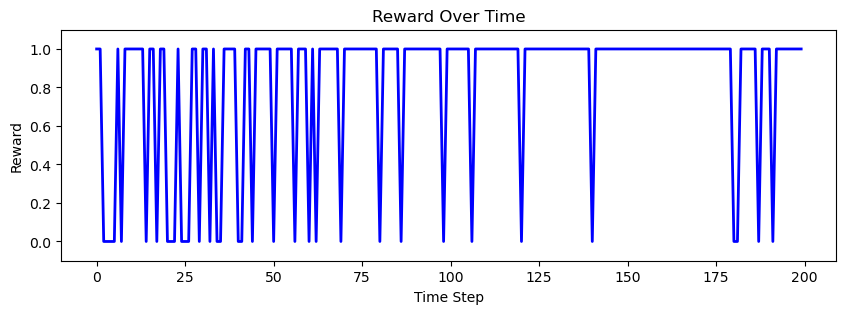

In [9]:
results = []

for i in range(B):

    # Initialize history buffers
    exp_history = ExperimentHistory()
    sub_history = IOPFSubjectHistory()

    # Initialize ensemble
    subject = IdealObsPFJCRP(N=250, hyp_params=HYP, n_workers=8)
    for j in range(n_blocks):

        env.repeat_trials(
            subject,
            experiment_history=exp_history,
            subject_history=sub_history,
            N=ctx_length,
            c=0,
            print_level=3,
        )
        env.repeat_trials(
            subject,
            experiment_history=exp_history,
            subject_history=sub_history,
            N=ctx_length,
            c=1,
            print_level=3,
        )

    subject.deallocate()

    # Combine histories into single object
    combined_history = CombinedHistory(
        subject_history=sub_history, experiment_history=exp_history
    )

    results.append(combined_history)

    plt.figure(figsize=(10, 3))
    plt.plot(
        combined_history.experiment_history.reward,
        label="Reward",
        color="blue",
        linewidth=2,
    )
    plt.title("Reward Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Reward")
    plt.ylim(-0.1, 1.1)
    plt.show()

In [10]:
proportion_optimal_mean = np.zeros(T)

chosen = list(range(B))

for j in chosen:

    proportion_optimal_mean += np.array(results[j].experiment_history.reward)

proportion_optimal_mean /= len(chosen)

# gaussian blur with kernel size 5 and sigma 1
from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)

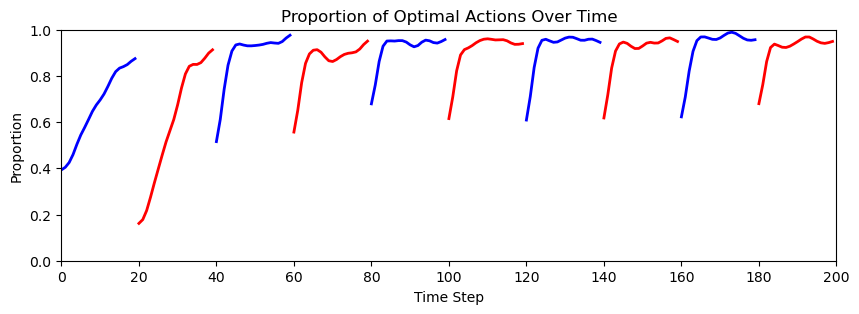

In [11]:
plt.figure(figsize=(10, 3))

for start in range(0, T, ctx_length):
    end = min(start + ctx_length, T)
    task = smooth(proportion_optimal_mean[start:end])
    duration = np.arange(start, end)

    # Alternate blue/red
    color = "blue" if (start // ctx_length) % 2 == 0 else "red"

    plt.plot(duration, task, color=color, linewidth=2)

plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, T)
plt.xticks(range(0, T + 1, ctx_length))

plt.show()

## Part 3: Analysis of Results

#### Sanity check of inferred parameters

### Visualisation of Results

In [12]:
print(type(results[j]))
print(vars(results[j]).keys())
print(vars(results[j].experiment_history).keys())
print(vars(results[j].subject_history).keys())

<class 'experiment.CombinedHistory'>
dict_keys(['experiment_history', 'subject_history'])
dict_keys(['state', 'context_o', 'context_r', 'observation', 'optimal_action', 'action', 'reward'])
dict_keys(['p_action', 'p_state', 'p_jump', 'context_o', 'context_r', 'weights'])


Context History:


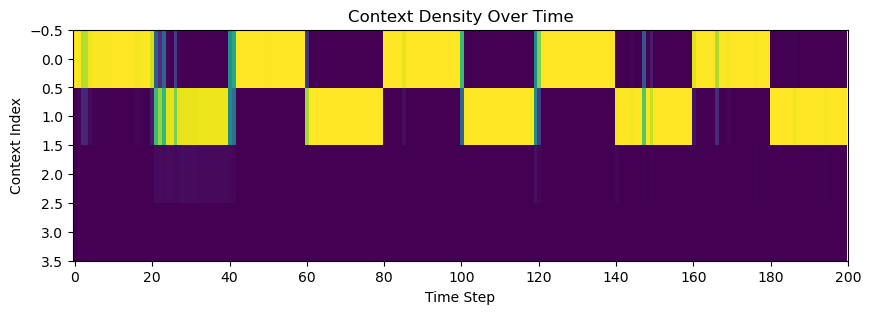

Actions History:


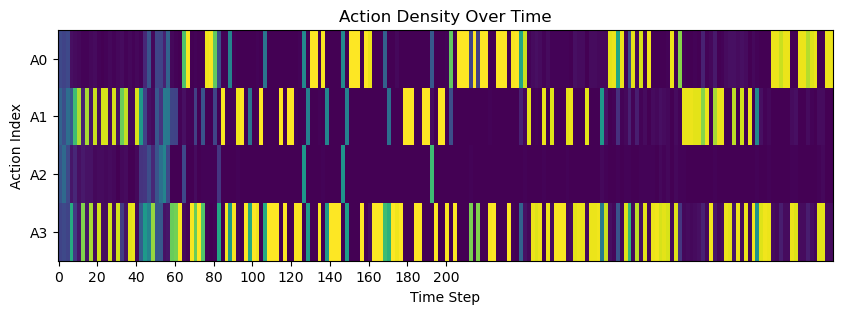

Proportion of Optimal Actions Over Time:


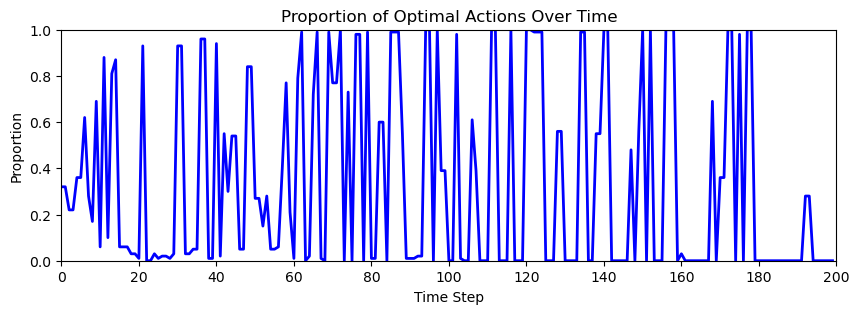

Jump History:


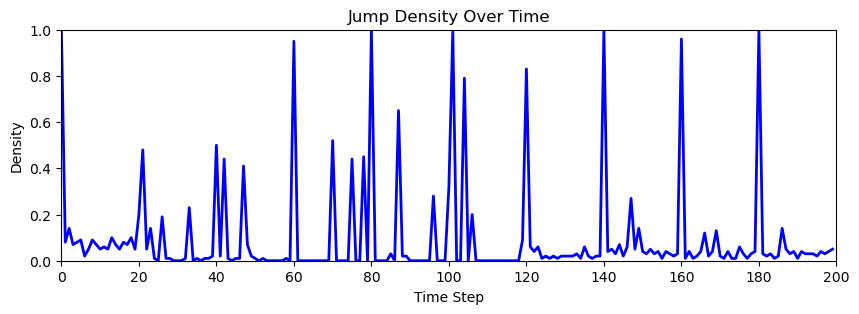

Inferred S History:


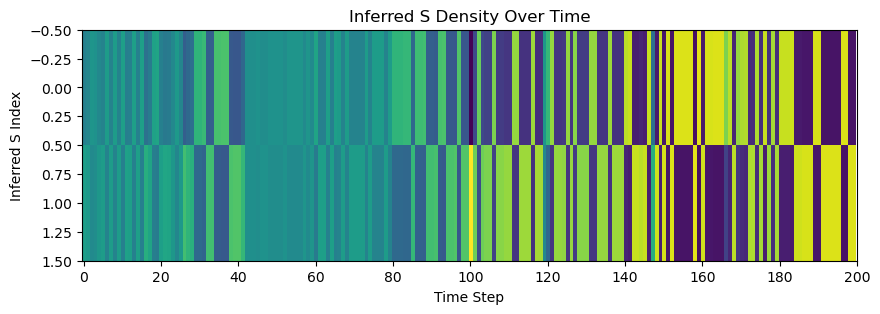

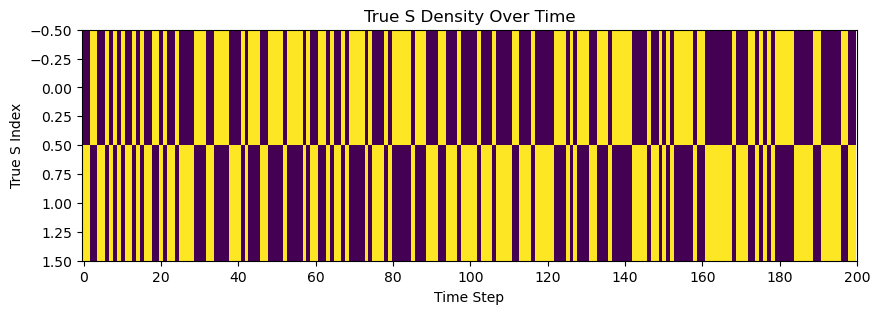

In [13]:
jump_times = []
j = 0
context_o_hist_arr = np.array(results[j].subject_history.context_o)
context_r_hist_arr = np.array(results[j].subject_history.context_r)
p_actions_arr = np.array(results[j].subject_history.p_action)
p_jump_arr = np.array(results[j].subject_history.p_jump)
p_state_arr = np.array(results[j].subject_history.p_state)
weight_arr = np.array(results[j].subject_history.weights)
p_action_optimal = results[j].p_optimal_action

print("Context History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(
    axis=1, keepdims=True
)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(
    context_o_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)


plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context Density Over Time")
# plt.savefig("g_context_o_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()


print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=["A0", "A1", "A2", "A3"])
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Action Index")
plt.title("Action Density Over Time")
# plt.savefig("g_action_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Proportion of Optimal Actions Over Time:")

plt.figure(figsize=(10, 3))
plt.plot(p_action_optimal, label="Proportion Optimal Action", color="blue", linewidth=2)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(p_action_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_proportion_optimal.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label="Jump", color="blue", linewidth=2)
plt.title("Jump Density Over Time")
plt.xlabel("Time Step")
plt.ylabel("Density")
plt.ylim(0, 1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_jump_density.pdf")
plt.xticks(range(0, T + 1, ctx_length))
plt.show()

print("Inferred S History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_state_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Inferred S Index")
plt.title("Inferred S Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_inferred_s_density.pdf")
plt.show()


true_s_hist_arr = np.asarray(results[j].experiment_history.state)

plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, val] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True)
plt.imshow(true_s_densities.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("True S Index")
plt.title("True S Density Over Time")
plt.xticks(range(0, T + 1, ctx_length))
# plt.savefig("g_true_s_density.pdf")
plt.show()